### Enhancing Noise Robustness in Spoken Digit Recognition \ Group 3: Marina (Yihe) Xu, Joseph Kung, Michelle Pan, Oliver Wang

In [42]:
# import google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
# replace <PATH-TO-YOUR-ZIP> with the path on your google drive
# Example: ! unzip /content/drive/MyDrive/Colab_Notebooks/M214_project_data.zip -d /content/
! unzip /content/drive/MyDrive/Colab_Notebooks/M214_project_data.zip -d /content/

unzip:  cannot find or open /content/drive/MyDrive/Colab_Notebooks/M214_project_data.zip, /content/drive/MyDrive/Colab_Notebooks/M214_project_data.zip.zip or /content/drive/MyDrive/Colab_Notebooks/M214_project_data.zip.ZIP.


In [ ]:
import os
import random
import numpy as np
import copy

# Set before CUDA ops for deterministic CUDA kernels.
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchaudio
import librosa
from glob import glob

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

#To select the feature extraction method:
VERSION = 1 #1 for OpenSmile method, change to 0 for Spectral Subtraction

In [45]:
# ============================================================
# Dataset paths
# ============================================================
base_dir = "/content/drive/MyDrive/ColabNotebooks/ECE214A/M214_project_data/"
TRAIN_DIR      = base_dir+"train_clean"
TEST_CLEAN_DIR = base_dir+"test_clean"
TEST_NOISY_5DB_DIR  = base_dir+"test_snr_5db_babble"
TEST_NOISY_10DB_DIR = base_dir+"test_snr_10db_babble"

# ============================================================
# Audio loading
# ============================================================

def load_audio(audio_file):
    audio, fs = torchaudio.load(audio_file)
    audio = audio.numpy().reshape(-1)
    return audio, int(fs)

In [46]:
def spectral_subtract_denoise(audio, fs, n_fft=256, hop_length=80, win_length=200,
                              noise_seconds=0.5, alpha=1.5, beta=0.02):

    #Spectral subtraction is used to denoise an audio by removing an estimated noise floor.

    audio = np.asarray(audio, dtype=np.float32)

    # STFT
    S = librosa.stft(
        audio,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length,
        center=True
    )

    mag = np.abs(S)
    phase = np.angle(S)

    # Noise spectrum estimation
    n_noise_frames = max(1, int((noise_seconds * fs) / hop_length))
    n_noise_frames = min(n_noise_frames, mag.shape[1])

    noise_mag = np.mean(mag[:, :n_noise_frames], axis=1, keepdims=True)

    # Spectral subtraction
    clean_mag = mag - alpha * noise_mag
    clean_mag = np.maximum(clean_mag, beta * noise_mag)

    # Reconstruct signal
    S_clean = clean_mag * np.exp(1j * phase)

    audio_clean = librosa.istft(
        S_clean,
        hop_length=hop_length,
        win_length=win_length,
        length=len(audio)
    )

    return np.asarray(audio_clean, dtype=np.float32)


def extract_feature_spectralSubtract(audio, fs):
    # Extract feature method from the baseline code,
    # now with spectral subtraction, pre-emphasis, deltas, and normalization

    N_MFCC = 13
    WIN_LENGTH = 200
    HOP_LENGTH = 80
    N_FFT = 256

    audio = np.asarray(audio, dtype=np.float32)


    #  Spectral subtraction

    audio = spectral_subtract_denoise(
        audio,
        fs,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        noise_seconds=0.5,
        alpha=1.5,
        beta=0.02
    )


    # Pre-emphasis

    preemph = 0.97
    audio = np.append(audio[0], audio[1:] - preemph * audio[:-1]).astype(np.float32)


    # . MFCC

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=fs,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH
    ).astype(np.float32)

    # Deltas

    delta = librosa.feature.delta(
        mfcc, width=9, order=1, mode="nearest"
    ).astype(np.float32)

    delta2 = librosa.feature.delta(
        mfcc, width=9, order=2, mode="nearest"
    ).astype(np.float32)


    #  Stack features

    feats = np.vstack([mfcc, delta, delta2]).astype(np.float32)

 # CMVN normalization

    mu = np.mean(feats, axis=1, keepdims=True)
    sigma = np.std(feats, axis=1, keepdims=True) + 1e-8
    feats = (feats - mu) / sigma

    return feats

In [47]:
!pip install opensmile

In [48]:
import numpy as np
import opensmile
import librosa
import os

In [49]:
#Set up opensmile
smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.IS11,
    feature_level=opensmile.FeatureLevel.LowLevelDescriptors_Deltas,
)

def pre_emphasis(audio, coeff=0.97):
    # Simple pre-emphasis high pass filter
    audio = np.asarray(audio, dtype=np.float32)
    return np.append(audio[0], audio[1:] - coeff * audio[:-1])

def cmvn(feat):
    # Normalization
    # feat is (F, T)
    mean = np.mean(feat, axis=1, keepdims=True)
    std = np.std(feat, axis=1, keepdims=True) + 1e-8
    return (feat - mean) / std

def extract_feature(audio, fs):
    """Extract openSMILE feature from raw audio. Returns (F, T)."""
    audio = np.asarray(audio, dtype=np.float32)

    # 1) pre-emphasis
    audio = pre_emphasis(audio, coeff=0.97)

    # OpenSMILE expects (channels, samples)
    if audio.ndim == 1:
        audio = audio[np.newaxis, :]

    # OpenSMILE returns (T, F)
    df = smile.process_signal(audio, fs)

    # convert to (F, T)
    feat = df.to_numpy().T.astype(np.float32)

    # 2) cepstral/feature normalization
    feat = cmvn(feat)

    return feat

def extract_feature_from_file(audio_file,version=1):
    audio, fs = load_audio(audio_file)
    if version==0:
      return extract_feature_spectralSubtract(audio, fs)
    else:
      return extract_feature(audio, fs)


In [50]:
# ============================================================
# Dataset & DataLoader
# ============================================================

class FeatureDataset(torch.utils.data.Dataset):
    def __init__(self, X_list, y):
        self.X = X_list          # list of (F, T) np arrays
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx])  # (F, T)
        return x, int(self.y[idx]), x.shape[1]


def collate_pad(batch):
    xs, ys, lens = zip(*batch)
    B = len(xs)
    F = xs[0].shape[0]
    T_max = max(lens)
    xb = torch.zeros(B, 1, F, T_max, dtype=xs[0].dtype)
    for i, x in enumerate(xs):
        xb[i, 0, :, :x.shape[1]] = x
    return xb, torch.tensor(ys, dtype=torch.long), torch.tensor(lens, dtype=torch.long)

# ============================================================
# Data loading
# ============================================================

def get_label(file_name):
    base = os.path.splitext(os.path.basename(file_name))[0]
    return int(base.split("_")[0])


def load_dir(data_dir, desc="Loading"):
    files = sorted(glob(os.path.join(data_dir, "*.wav")))
    if not files:
        print(f"No wav files found in {data_dir}")
        return [], []
    feats, labels = [], []
    for wav in files:
        feats.append(extract_feature_from_file(wav,version=VERSION))
        labels.append(get_label(wav))
    print(f"  {desc}: {len(feats)} files loaded")
    return feats, labels

In [51]:
# ============================================================
# LSTM model
# ============================================================

class SimpleLSTM(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=128, num_layers=2,
            batch_first=True, bidirectional=True,
            dropout=0.2
        )
        self.classifier = nn.Sequential(
            nn.Linear(256, 32), nn.ReLU(), nn.Dropout(0.3), nn.Linear(32, 10),
        )

    def forward(self, x, lengths):
        # x: (B,1,F,T) -> (B,T,F)
        x = x.squeeze(1).permute(0, 2, 1).contiguous()

        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)  # (B, T_max, 256)

        # ---- mean pooling over valid frames (ignore padding) ----
        B, T_max, D = out.shape
        device = out.device

        # mask: (B, T_max), True for valid timesteps
        mask = torch.arange(T_max, device=device).unsqueeze(0) < lengths.unsqueeze(1)

        # expand mask to (B, T_max, D) and zero-out padding
        mask_f = mask.unsqueeze(-1).float()
        out_sum = (out * mask_f).sum(dim=1)                       # (B, D)
        denom = mask_f.sum(dim=1).clamp(min=1.0)                  # (B, 1)
        mean = out_sum / denom                                    # (B, D)

        return self.classifier(mean)

In [52]:
# ============================================================
# Evaluation
# ============================================================

import matplotlib.pyplot as plt
from sklearn import metrics

@torch.no_grad()
def evaluate(model, loader, device, plot_cm=False, class_names=None, title=None, save_path=None):
    """
    Returns:
      acc (float) by default.
      If plot_cm=True, also returns (acc, cm).
    """
    model.eval()
    if loader is None:
        return (0.0, None) if plot_cm else 0.0

    all_preds = []
    all_labels = []

    correct, total = 0, 0
    for xb, yb, lengths in loader:
        xb, yb, lengths = xb.to(device), yb.to(device), lengths.to(device)
        logits = model(xb, lengths)
        preds = logits.argmax(dim=1)

        correct += (preds == yb).sum().item()
        total += yb.size(0)

        if plot_cm:
            all_preds.append(preds.detach().cpu().numpy())
            all_labels.append(yb.detach().cpu().numpy())

    acc = correct / total if total > 0 else 0.0

    if not plot_cm:
        return acc

    y_pred = np.concatenate(all_preds) if all_preds else np.array([], dtype=np.int64)
    y_true = np.concatenate(all_labels) if all_labels else np.array([], dtype=np.int64)

    cm = metrics.confusion_matrix(y_true, y_pred, labels=None)

    # Plot
    disp = metrics.ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names if class_names is not None else None
    )
    disp.plot(values_format="d")
    plt.title(title or "Confusion Matrix")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150)
        plt.close()
    else:
        plt.show()

    return acc, cm

In [53]:
# Training
BATCH_SIZE = 32
NUM_EPOCHS = 40
LR = 3e-4

In [54]:
# --- Load data ---
train_feat, train_label   = load_dir(TRAIN_DIR, desc="Train")
test_feat,  test_label    = load_dir(TEST_CLEAN_DIR, desc="Test clean")
noisy5_feat, noisy5_label = load_dir(TEST_NOISY_5DB_DIR, desc="Test noisy 5dB")
noisy10_feat, noisy10_label = load_dir(TEST_NOISY_10DB_DIR, desc="Test noisy 10dB")

feat_dim = train_feat[0].shape[0]
print(f"\nFeature dim: {feat_dim}")
print(f"Train: {len(train_feat)}  |  Test clean: {len(test_feat)}  "
      f"|  Test noisy 5dB: {len(noisy5_feat)}  |  Test noisy 10dB: {len(noisy10_feat)}")

for name, flist in [("Train", train_feat), ("Test clean", test_feat),
                    ("Noisy 5dB", noisy5_feat), ("Noisy 10dB", noisy10_feat)]:
    if flist:
        lengths = [f.shape[1] for f in flist]
        print(f"  {name:10s} frames: min={min(lengths)}, max={max(lengths)}, mean={np.mean(lengths):.1f}")

y_train   = np.array(train_label, dtype=np.int64)
y_test    = np.array(test_label,  dtype=np.int64)
y_noisy5  = np.array(noisy5_label, dtype=np.int64)
y_noisy10 = np.array(noisy10_label, dtype=np.int64)

# --- DataLoaders ---
loader_g = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    FeatureDataset(train_feat, y_train),
    batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_pad, generator=loader_g,
)
test_loader = DataLoader(
    FeatureDataset(test_feat, y_test),
    batch_size=16, shuffle=False, collate_fn=collate_pad
)
noisy5_loader = None
if noisy5_feat:
    noisy5_loader = DataLoader(
        FeatureDataset(noisy5_feat, y_noisy5),
        batch_size=16, shuffle=False, collate_fn=collate_pad,
    )
noisy10_loader = None
if noisy10_feat:
    noisy10_loader = DataLoader(
        FeatureDataset(noisy10_feat, y_noisy10),
        batch_size=16, shuffle=False, collate_fn=collate_pad,
    )

# --- Training ---
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = SimpleLSTM(input_size=feat_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=LR)

best_clean, best_clean_ep = 0.0, -1
best_5db,  best_5db_ep  = 0.0, -1
best_10db, best_10db_ep = 0.0, -1

"""
Save the checkpoint with the best 10 dB accuracy.
You may instead choose to save the model with the best clean or 5 dB accuracy,
but keep in mind that your final score depends on strong performance on all of the test sets, especially the noisy test set.
"""
saved_checkpoint = None

for epoch in range(1, NUM_EPOCHS + 1):
    net.train()
    total_loss = 0.0
    for xb, yb, lengths in train_loader:
        xb, yb, lengths = xb.to(device), yb.to(device), lengths.to(device)
        optimizer.zero_grad()
        loss = criterion(net(xb, lengths), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * xb.size(0)

    avg_loss = total_loss / len(train_loader.dataset)
    clean_acc = evaluate(net, test_loader, device)
    acc_5db  = evaluate(net, noisy5_loader, device)
    acc_10db = evaluate(net, noisy10_loader, device)

    print(f"Epoch {epoch:02d}  loss={avg_loss:.4f}  "
          f"clean={clean_acc:.4f}  5dB={acc_5db:.4f}  10dB={acc_10db:.4f}")

    if clean_acc > best_clean:
        best_clean, best_clean_ep = clean_acc, epoch
    if acc_5db > best_5db:
        best_5db, best_5db_ep = acc_5db, epoch
    if acc_10db > best_10db:
        best_10db, best_10db_ep = acc_10db, epoch
        saved_checkpoint = copy.deepcopy(net.state_dict())  # save the best checkpoint

  Train: 2500 files loaded
  Test clean: 300 files loaded
  Test noisy 5dB: 300 files loaded
  Test noisy 10dB: 300 files loaded

Feature dim: 59
Train: 2500  |  Test clean: 300  |  Test noisy 5dB: 300  |  Test noisy 10dB: 300
  Train      frames: min=11, max=225, mean=40.2
  Test clean frames: min=11, max=111, mean=39.6
  Noisy 5dB  frames: min=11, max=111, mean=39.6
  Noisy 10dB frames: min=11, max=111, mean=39.6
Epoch 01  loss=2.2690  clean=0.2033  5dB=0.1867  10dB=0.1967
Epoch 02  loss=1.5800  clean=0.7833  5dB=0.6600  10dB=0.7400
Epoch 03  loss=0.8539  clean=0.8867  5dB=0.6500  10dB=0.7733
Epoch 04  loss=0.4809  clean=0.8900  5dB=0.6900  10dB=0.8067
Epoch 05  loss=0.3283  clean=0.9433  5dB=0.6733  10dB=0.8100
Epoch 06  loss=0.2198  clean=0.9433  5dB=0.6533  10dB=0.7867
Epoch 07  loss=0.1622  clean=0.9667  5dB=0.7033  10dB=0.8267
Epoch 08  loss=0.1024  clean=0.9533  5dB=0.7067  10dB=0.8133
Epoch 09  loss=0.0802  clean=0.9700  5dB=0.7200  10dB=0.8567
Epoch 10  loss=0.0623  clean=0.9

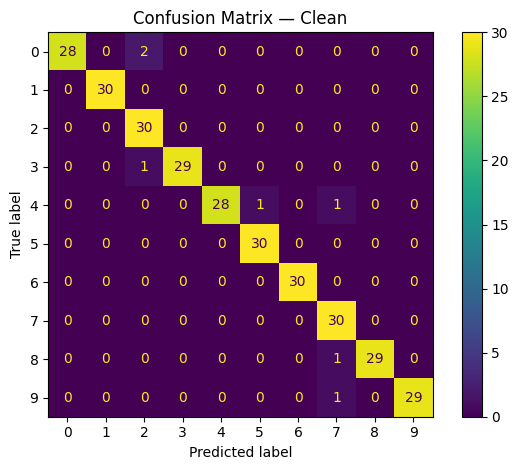

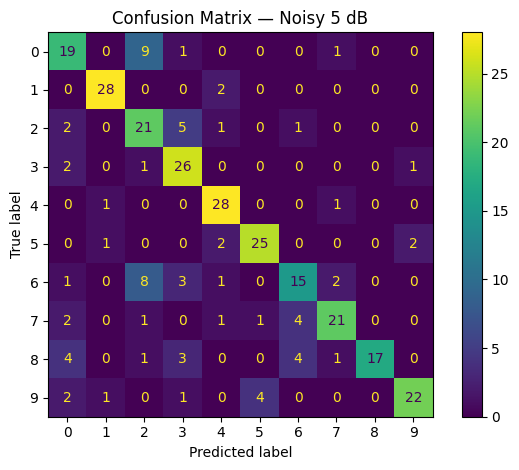

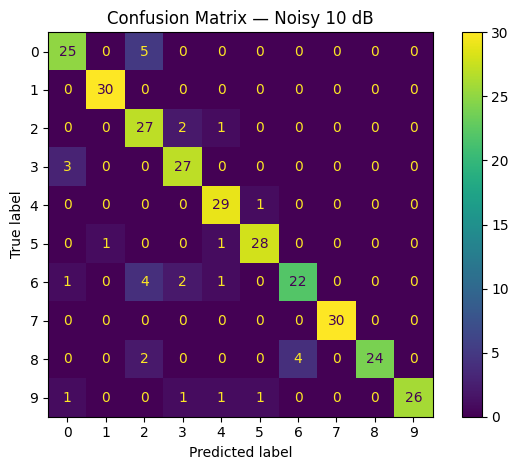


Best checkpoint loaded (epoch 31)
Clean accuracy : 0.9767
5dB accuracy   : 0.7400
10dB accuracy  : 0.8933


In [55]:
# load the best checkpoint before testing
net = SimpleLSTM(input_size=feat_dim).to(device)
net.load_state_dict(saved_checkpoint)
# clean_acc = evaluate(net, test_loader, device)
clean_acc, cm_clean = evaluate(
    net, test_loader, device,
    plot_cm=True,
    class_names=list(range(10)),
    title="Confusion Matrix — Clean"
)
acc_5db, cm_5db = evaluate(
    net, noisy5_loader, device,
    plot_cm=True,
    class_names=list(range(10)),
    title="Confusion Matrix — Noisy 5 dB"
)
acc_10db, cm_10db = evaluate(
    net, noisy10_loader, device,
    plot_cm=True,
    class_names=list(range(10)),
    title="Confusion Matrix — Noisy 10 dB"
)
print(f"\nBest checkpoint loaded (epoch {best_10db_ep})")
print(f"Clean accuracy : {clean_acc:.4f}")
print(f"5dB accuracy   : {acc_5db:.4f}")
print(f"10dB accuracy  : {acc_10db:.4f}")